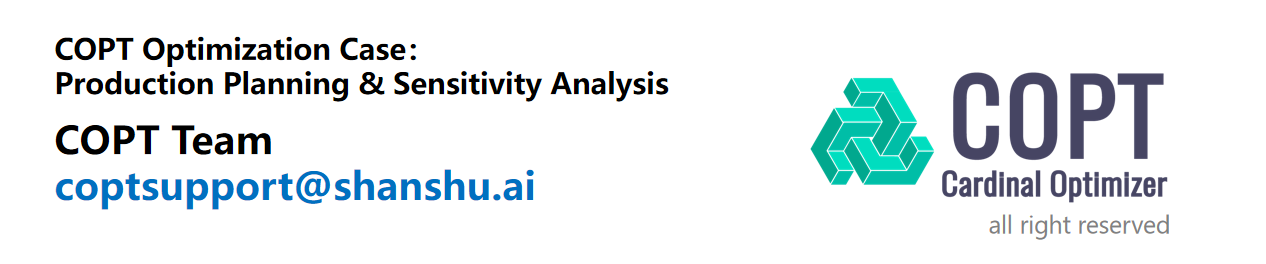

> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


# Production Planning & Sensitivity Analysis: Code Implementation
## Steps to Model and Solve Production Planning Problem and Perform Sensitivity Analysis using COPT
1. **Import COPT-Python interface library** `coptpy`

2. **Create COPT solving environment and model**

3. **Build the model and add the three elements of the model in sequence**
    - **Decision Variables**:
        - Continuous non-negative decision variable $X_i$, representing the production quantity (pieces) of variant $i$ within the planning year.
    - **Objective Function**:
        - Maximize total profit.
    - **Constraints**:
        - Assembly working hours upper limit constraint.
        - Polishing working hours upper limit constraint.
        - Packaging working hours upper limit constraint.

4. **Solve**

5. **Sensitivity Analysis**:
    - Under what interval of changes in objective function coefficients (profit) does the current optimal basis remain unchanged?
    - Under what interval of changes in variable lower/upper bounds does the current optimal basis remain unchanged?
    - Under what interval of changes in the left/right hand side (LHS/RHS) of constraints does the current basis remain optimal?

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT
import numpy as np
import matplotlib.pyplot as plt

## Create the COPT Environment and COPT Model

In [6]:
env = cp.Envr()
model = env.createModel("Production Planning Problem")
# Enable sensitivity analysis
model.param.ReqSensitivity = 1

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved

Setting parameter 'ReqSensitivity' to 1


**<span style="color:rgb(0,0,255)">Note: Sensitivity analysis results are not output by default, the parameter needs to be set before solving.</span>**

```python
# Enable sensitivity analysis
model.param.ReqSensitivity = 1
```

After setting this parameter, when `solve()` is called and the linear program is solved by the simplex method, the solver will automatically calculate the allowable variation ranges for each objective coefficient and constraint right-hand side, without the need to call additional functions. Subsequently, the sensitivity interval results can be read through corresponding information. Note that sensitivity analysis requires an optimal basic solution (obtained via simplex method or crossover), so this feature is only applicable to linear programming (LP) problems.

## Add three core components of COPT Model
### Add Decision Variables
$X_i \in \mathbb{R}^+$：The production quantity (pieces) of variant $i$ within the planning year, a continuous non-negative variable, $i \in \{1, 2, 3, 4\}$。
- `X1`：Quantity of variant 1 produced in planning year. 
- `X2`：Quantity of variant 2 produced in planning year. 
- `X3`：Quantity of variant 3 produced in planning year. 
- `X4`：Quantity of variant 4 produced in planning year. 

In [9]:
X1 = model.addVar(lb=0.0, name="X1")
X2 = model.addVar(lb=0.0, name="X2")
X3 = model.addVar(lb=0.0, name="X3")
X4 = model.addVar(lb=0.0, name="x4")

### Set Objective Function
Maximize the annual total profit:
$$ \max 1.5 X_1 + 2.5 X_2 + 3.0 X_3 + 4.5 X_4 $$

In [11]:
model.setObjective(1.5 * X1 + 2.5 * X2 + 3.0 * X3 + 4.5 * X4, COPT.MAXIMIZE)

### Add Constraints
1. **Assembly working hours upper limit constraint**：The total assembly working hours consumed by all variants must not exceed the system's assembly capacity upper limit.
$$ 2X_1 + 4X_2 + 3X_3 + 7X_4 \le 100000 $$

In [13]:
model.addConstr(2 * X1 + 4 * X2 + 3 * X3 + 7 * X4 <= 100000, name="AssemblyTime")

<coptpy.Constraint: AssemblyTime>

2. **Polishing working hours upper limit constraint**: The total polishing working hours consumed by all variants must not exceed the system's polishing capacity upper limit.
$$ 3X_1 + 2X_2 + 3X_3 + 4X_4 \le 50000 $$

In [15]:
model.addConstr(3 * X1 + 2 * X2 + 3 * X3 + 4 * X4 <= 50000, name="PolishTime")

<coptpy.Constraint: PolishTime>

3. **Packaging working hours upper limit constraint**: The total packaging working hours consumed by all variants must not exceed the system's packaging capacity upper limit.
$$ 2X_1 + 3X_2 + 2X_3 + 5X_4 \le 60000 $$

In [17]:
model.addConstr(2 * X1 + 3 * X2 + 2 * X3 + 5 * X4 <= 60000, name="PackTime")

<coptpy.Constraint: PackTime>

## Solve

In [19]:
model.solve()

Model fingerprint: eafe3cc4

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    3 rows, 4 columns and 12 non-zero elements
The presolved problem has:
    3 rows, 4 columns and 12 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [5e-01,2e+00]
    Range of rhs coefficients:       [5e+04,1e+05]
    Range of bound coefficients:     [0e+00,0e+00]
    Range of cost coefficients:      [6e-01,2e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    1.7900248463e+05            3           0       0.03s
Dual             4    5.8000255410e+04            0           0       0.03s
Postsolving
Dual             4    5.8000000000e+04            0           0       

## Retrieve Results
### Print the Optimal Solution of the Model

In [21]:
def print_result(model):
    print("\n===== Optimal Solution =====")

    # 1. Print objective value
    print(f"Objective value: {model.objval}")

    # 2. Print variable values
    print("\nDecision Variables:")
    allvars = model.getVars()
    for var in allvars:
        print("{0} Optimal value: {1:.4f}, Basis status:{2}, Reduced cost：{3:.4f}".format(var.name, var.x, int(var.basis), var.rc))

    # 3. Print constraint slack and dual values
    print("\nConstraints:")
    for c in model.getConstrs():
        row = model.getRow(c)
        slack = c.Slack
        dual = c.Pi  # Dual value (shadow price)
        print(f"  {c.name}: Slack = {slack}, Dual = {dual}")


In [22]:
if model.status == COPT.OPTIMAL:
    print_result(model)
else:
    print("No optimal solution.")


===== Optimal Solution =====
Objective value: 58000.0

Decision Variables:
X1 Optimal value: 0.0000, Basis status:0, Reduced cost：-1.5000
X2 Optimal value: 16000.0000, Basis status:1, Reduced cost：-0.0000
X3 Optimal value: 6000.0000, Basis status:1, Reduced cost：-0.0000
x4 Optimal value: 0.0000, Basis status:0, Reduced cost：-0.2000

Constraints:
  AssemblyTime: Slack = 82000.0, Dual = 0.0
  PolishTime: Slack = 50000.0, Dual = 0.8
  PackTime: Slack = 60000.0, Dual = 0.2999999999999998


- **Decision Variable Basis Status**: The basis status values for decision variables X2 and X3 are 1. According to the simplex method theory in linear programming, under non-degenerate conditions, this indicates that X2 and X3 are **Basic Variables** constituting the current optimal solution.
- **Reduced Cost**: According to the simplex method theory, the reduced cost of a decision variable corresponds to its optimality condition value ($\sigma_j$) in the simplex tableau. When reaching the optimal solution state, the reduced cost of basic variables that have been selected into the production plan is always 0; while the reduced cost of non-basic variables that have not been put into production is non-zero.

**Interpretation of Economic Significance**:

**Reduced cost** intuitively reflects the marginal impact on the objective function value of making a minor perturbation (such as forced scheduling of production) to the decision variable under the current optimal decision. For profit maximization problems, if the reduced cost of a decision variable is $<0$, it explicitly indicates that the variant is currently not worth producing. In other words, if 1 piece of this variant is forcibly produced, it will not only fail to increase revenue but will squeeze out other more valuable resources, resulting in a corresponding decrease in total profit. Only when the unit profit of this variant increases by at least this difference, does it have the economic value to resume production.

### Print Sensitivity Analysis Results

In the COPT solver, sensitivity analysis results are obtained by querying specific information of variables and constraints (COPT.Info class). Here is common information for COPT solving and sensitivity analysis results:

| Information Name | Description |
| :--- |  :--- |
| `SAObjLow` | Lower bound of sensitivity analysis for objective function coefficients |
| `SAObjUp` | Upper bound of sensitivity analysis for objective function coefficients |
| `SALBLow` | Lower bound of sensitivity analysis for variable or constraint lower bound |
| `SALBUp` | Upper bound of sensitivity analysis for variable or constraint lower bound |
| `SAUBLow` | Lower bound of sensitivity analysis for variable or constraint upper bound |
| `SAUBUp` | Upper bound of sensitivity analysis for variable or constraint upper bound |

1. For **objective function coefficients**, such as the unit profit of each variant in this case, their allowable variation interval represents the safe range within which profit can fluctuate while keeping the current optimal production strategy unchanged. This interval can be obtained via `COPT.Info.SAObjLow` and `COPT.Info.SAObjUp`.

2. For **model constraints**, COPT internally uses a unified two-sided constraint format, i.e., $L \le Ax \le U$.
   - For $\le$ constraints, such as the capacity upper limit constraints in this case, the focus is on the **upper bound** (RHS in the output). Its allowable variation interval is obtained via `COPT.Info.SAUBLow` and `COPT.Info.SAUBUp`.
   - For $\ge$ constraints, the focus is on the **lower bound** (LHS in the output). Its allowable variation interval is obtained via `COPT.Info.SALBLow` and `COPT.Info.SALBUp`.

In [25]:
def print_sensitivity(model):
    vars = model.getVars()
    cons = model.getConstrs()

    obj_low = model.getInfo(COPT.Info.SAObjLow, vars)
    obj_upp = model.getInfo(COPT.Info.SAObjUp, vars)
    print("")
    print("Variant\tObjective Range")
    for i in range(vars.size):
        print(f"  {vars[i].name}\t({obj_low[i]}, {obj_upp[i]})")

    lb_low = model.getInfo(COPT.Info.SALBLow, vars)
    lb_upp = model.getInfo(COPT.Info.SALBUp, vars)
    ub_low = model.getInfo(COPT.Info.SAUBLow, vars)
    ub_upp = model.getInfo(COPT.Info.SAUBUp, vars)
    print("")
    print("Variant\tLowBound Range  \tUppBound Range")
    for i in range(vars.size):
        print(f"  {vars[i].name}\t({lb_low[i]}, {lb_upp[i]})\t({ub_low[i]}, {ub_upp[i]})")

    rowlb_low = model.getInfo(COPT.Info.SALBLow, cons)
    rowlb_upp = model.getInfo(COPT.Info.SALBUp, cons)
    rowub_low = model.getInfo(COPT.Info.SAUBLow, cons)
    rowub_upp = model.getInfo(COPT.Info.SAUBUp, cons)
    print("")
    print("Constraint\tLHS Range         \tRHS Range")
    for i in range(cons.size):
        print(f"  {cons[i].name}\t({rowlb_low[i]}, {rowlb_upp[i]})\t({rowub_low[i]}, {rowub_upp[i]})")

In [26]:
# Show the results of sensitivity analysis
if model.status == COPT.OPTIMAL:
    if model.HasSensitivity:
        print("")
        print("Sensitivity information of production planning problem:")
        print_sensitivity(model)
    else:
        print("Sensitivity information is not available")
else:
    print("Optimal solution is not available, with status " + str(model.status))


Sensitivity information of production planning problem:

Variant	Objective Range
  X1	(-1e+30, 3.0)
  X2	(2.3571428571428577, 4.5)
  X3	(2.5000000000000018, 3.7499999999999996)
  x4	(-1e+30, 4.699999999999999)

Variant	LowBound Range  	UppBound Range
  X1	(-18000.0, 6000.0)	(0.0, 1e+30)
  X2	(-1e+30, 16000.0)	(16000.0, 1e+30)
  X3	(-1e+30, 6000.0)	(6000.0, 1e+30)
  x4	(-1e+30, 11428.571428571431)	(0.0, 1e+30)

Constraint	LHS Range         	RHS Range
  AssemblyTime	(-1e+30, 82000.0)	(82000.0, 1e+30)
  PolishTime	(-1e+30, 50000.0)	(40000.0, 90000.0)
  PackTime	(-1e+30, 60000.0)	(33333.33333333333, 75000.0)


Through the sensitivity analysis results, we can know the allowable variation intervals of key parameters under the premise of keeping the current optimal production strategy unchanged:

1. **Allowable Fluctuation Interval of Objective Function Coefficients**:

There is a clear safe fluctuation interval for the unit profit of each product variant. Taking variant 2 as an example, its current profit is 2.50 Yuan, and the sensitivity analysis shows its variation interval is 2.36 to 4.50 Yuan. This means that as long as the market price fluctuation does not drop below 2.36 Yuan or surge beyond 4.50 Yuan, the current production mix remains optimal. For the unproduced variant 4, its current profit of 4.50 Yuan is very close to the right upper boundary of 4.70 Yuan. A slight market premium of 0.20 Yuan will necessitate an adjustment of the overall production mix.

2. **Allowable Fluctuation Interval of Constraint Boundaries**:

Taking assembly working hours as an example, this is an upper limit constraint with an original system design capacity of 100,000 minutes. The output shows its upper limit variation interval is 82000.00 to positive infinity. This is because only 82,000 minutes were actually consumed in production. As long as the total assembly capacity of the system is not lower than this actual consumption, it will not have any impact on the current optimal production plan. Conversely, the upper limit variation interval for polishing working hours is 40000.00 to 90000.00 minutes. This provides a quantifiable safe decision boundary for capacity reduction caused by regular equipment maintenance or capacity expansion brought about by temporary overtime scheduling.

### Visualization of Sensitivity Analysis for Objective Function Coefficients

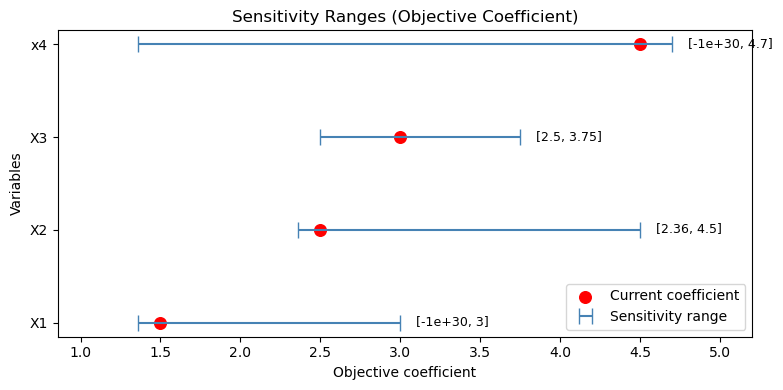

In [29]:
# 1. Read original sensitivity results
vars_ = model.getVars()
names = [v.name for v in vars_]

obj_low_raw = np.array(model.getInfo(COPT.Info.SAObjLow, vars_), dtype=float)
obj_upp_raw = np.array(model.getInfo(COPT.Info.SAObjUp, vars_), dtype=float)
cur_coef = np.array([v.Obj for v in vars_], dtype=float)

# 2. Find finite bounds
finite_lows = obj_low_raw[obj_low_raw > -1e20]
finite_upps = obj_upp_raw[obj_upp_raw <  1e20]

min_finite = finite_lows.min()
max_finite = finite_upps.max()

# 3. Replace -inf/+inf
NEG_INF = min_finite - 1.0
POS_INF = max_finite + 1.0

low_plot = np.where(obj_low_raw < -1e20, NEG_INF, obj_low_raw)
upp_plot = np.where(obj_upp_raw >  1e20, POS_INF, obj_upp_raw)

# Midpoint + error
mid = (low_plot + upp_plot) / 2
err_low = mid - low_plot
err_upp = upp_plot - mid

# 4. Plot
fig, ax = plt.subplots(figsize=(8, 4))

# Horizontal lines for intervals
ax.errorbar(
    x=mid,
    y=names,
    xerr=[err_low, err_upp],
    fmt="none",
    ecolor="steelblue",
    capsize=6,
    label="Sensitivity range",
)

# Current objective coefficient
ax.scatter(
    cur_coef,
    names,
    marker="o",
    s=70,
    color="red",
    label="Current coefficient",
)

# Annotate original intervals
for i, name in enumerate(names):
    ax.text(
        upp_plot[i] + 0.1,
        name,
        f"[{obj_low_raw[i]:.3g}, {obj_upp_raw[i]:.3g}]",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Objective coefficient")
ax.set_ylabel("Variables")
ax.set_title("Sensitivity Ranges (Objective Coefficient)")

# Auto xlim
ax.set_xlim(min(low_plot) - 0.5, max(upp_plot) + 0.5)

ax.legend()
plt.tight_layout()
plt.show()


The chart above illustrates the allowable variation ranges for the profit coefficients of the four products, which is the interval within which the unit profit of each product can fluctuate while maintaining the current optimal production plan unchanged:

- For unproduced products (variant 1 and variant 4), their left sides extend to negative infinity (-1e+30). **The key turning point lies in the right boundary.** The current profit of variant 1 is far below the upper limit of the safe interval, making it extremely uncompetitive; whereas the current profit of variant 4 is very close to the upper limit that would trigger production. A slight market premium could restart its production.

- For produced products (variant 2 and variant 3), the current profit of variant 2 is close to the lower safe bound, making it quite sensitive to price-cut promotions or cost increases, warning of a higher risk of production suspension. In contrast, variant 3 is positioned more centrally within the interval, providing sales and pricing departments with more operational room, clarifying the maximum tolerable discount promotion and the safe range for price increases.

### Comparison of Resource Usage and Shadow Price Visualization

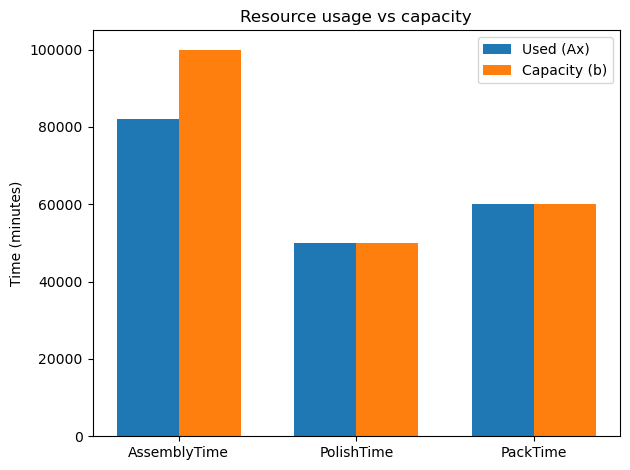

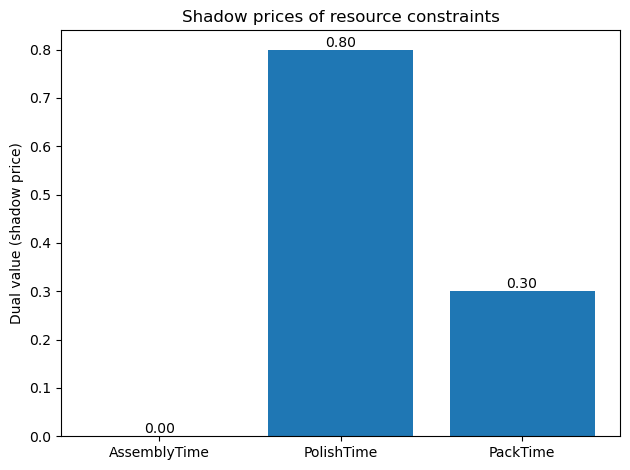

In [32]:
cons_ = model.getConstrs()

names = [c.name for c in cons_]
lhs_used = []   # Ax
rhs_cap = []    # RHS
duals = []      # Pi

for c in cons_:
    lhs_used.append(c.Slack)   # In COPT, Slack actually represents Ax (left hand side value)
    rhs_cap.append(c.UB)       
    duals.append(c.Pi)

lhs_used = np.array(lhs_used, dtype=float)
rhs_cap = np.array(rhs_cap, dtype=float)
duals = np.array(duals, dtype=float)

# Chart 1: Resource usage
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, lhs_used, width, label="Used (Ax)")
ax.bar(x + width/2, rhs_cap, width, label="Capacity (b)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Time (minutes)")
ax.set_title("Resource usage vs capacity")
ax.legend()
plt.tight_layout()
plt.show()

# Chart 2: Shadow prices
fig, ax = plt.subplots()
ax.bar(names, duals)
ax.set_ylabel("Dual value (shadow price)")
ax.set_title("Shadow prices of resource constraints")

for i, v in enumerate(duals):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


These two charts reveal the system bottlenecks in the production process and the marginal benefits that breaking these bottlenecks can yield.

- Regarding resource usage, the actual consumption in the assembly working hours is far below the upper limit constraint, indicating severe capacity idle. The core bottlenecks are the polishing and packaging stages, where working hours utilization reaches 100%, demonstrating that they are the central constraints restricting the enterprise from further expanding production scale and increasing profits.

- Regarding return on investment for capacity expansion, the shadow price for the surplus assembly working hours is 0, meaning that adding resources here is unprofitable. By comparison, polishing working hours have the highest shadow price, followed by packaging. If the enterprise has an extra capital budget for equipment expansion, it should prioritize resources to the polishing workshop, and then the packaging workshop, to obtain the maximum marginal profit.